In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd  # pandas is a popular library for data analysis

# Read a CSV (comma-separated values) file named 'data_science_job.csv'
# into a DataFrame. A DataFrame is like a table of data (similar to an Excel sheet)
# that allows easy data cleaning, filtering, and analysis in Python.
df = pd.read_csv('data_science_job.csv')

In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
# Calculate the percentage of missing (null) values in each column of the DataFrame
# Explanation:
# - df.isnull() returns a DataFrame of True/False values indicating which entries are missing
# - .mean() on this boolean DataFrame counts the fraction of missing values in each column
#   (since True counts as 1 and False as 0)
# - multiplying by 100 converts the fraction to a percentage
df.isnull().mean() * 100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


---

## **Your missingness report**

| Column                   | % Missing |
| ------------------------ | --------- |
| enrollee\_id             | 0%        |
| city                     | 0%        |
| city\_development\_index | 2.5%      |
| gender                   | 23.5%     |
| relevent\_experience     | 0%        |
| enrolled\_university     | 2.0%      |
| education\_level         | 2.4%      |
| major\_discipline        | 14.7%     |
| experience               | 0.34%     |
| company\_size            | 31%       |
| company\_type            | 32%       |
| training\_hours          | 4%        |
| target                   | 0%        |

---

## **Interpretation with respect to CCA**

✅ If you do **CCA on *all* columns**, you would keep **only rows that have zero missing values across every column.**<br>
👉 But columns like `gender` (23.5% missing), `major_discipline` (14.7% missing), `company_size` (31% missing), `company_type` (32% missing) would cause a **huge drop** in your usable data because those missing percentages are high.<br>

In other words:

* **columns with >20% missing** will cause you to lose a large fraction of your data if you apply CCA.
* even `city_development_index` at 2.5% or `training_hours` at 4% are tolerable, but the columns over 30% missing are very risky for CCA.

---

## **Summary judgment**

✅ **Columns with low missingness (<5%)**: safe for CCA, you won’t lose much data<br>
✅ **Columns with high missingness (>20%)**: using CCA will remove a large number of rows, possibly harming your analysis<br>

---

## **Typical strategy in this case:**

👉 *Don’t* blindly do CCA on the entire dataframe.<br>
👉 Instead:<br>

* use CCA for columns with *low* missingness (say under 5%)
* consider **imputation** for columns with higher missingness (e.g., fill gender with mode, or use `Unknown` for company\_type).

---

**In short**:<br>
✅ Applying CCA on all columns would leave you with very few rows because of high-missing columns<br>
✅ Applying CCA on a subset of columns with $<5\%$ missing is reasonable and data-efficient.

In this demo we will apply to 'city_development_index', 'enrolled_university','education_level','experience','training_hours'<br>

---

In [ ]:
df.shape

(19158, 13)

In [ ]:
# Create a list of columns that have:
#  - missing values (mean() > 0)
#  - but less than 5% missing (mean() < 0.05)
#
# Explanation:
# - df.columns gives you all column names
# - the list comprehension goes through each column (var)
# - df[var].isnull().mean() gives the fraction of missing values for that column
# - we keep only columns with missing data fraction between 0 and 0.05
#
# This is helpful if you want to fix columns with a *small* amount of missing data
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

# Show the selected columns
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [ ]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
5531,0.949,no_enrollment,High School,2.0,12.0
7774,0.910,no_enrollment,Graduate,7.0,51.0
17104,0.624,no_enrollment,Graduate,3.0,20.0
611,0.802,no_enrollment,Masters,11.0,35.0
6098,0.910,no_enrollment,Graduate,2.0,106.0


**enrolled_university** and **education_level** have categorical data in them

In [ ]:
df['education_level'].value_counts()

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [ ]:
len(df)

19158

In [ ]:
# Count how many rows in the DataFrame have *no missing values*
# for the columns listed in 'cols'
#
# Explanation:
# - df[cols] selects only the columns with small amounts of missing data (from earlier)
# - .dropna() removes any rows that have missing values in those selected columns
# - len() counts how many rows are left after dropping those with missing values
#
# So this tells you: "How many rows are fully complete (with NO NAs) for the columns with less than 5% missing?"
len(df[cols].dropna()) # 17182 - num of rows that don't have any NAs

17182

---

✅ **Interpretation**:
There are **17,182** rows in your dataset that have **complete data** in those columns with less than 5% missing.

Given the earlier calculation (about 90% coverage), this confirms you would still have a solid amount of data left if you chose to drop rows with missing values in those columns.

---

In [ ]:
# Calculate the proportion of rows that are *complete* (no missing values)
# in the selected columns ('cols'), relative to the total number of rows.
#
# Explanation:
# - df[cols] selects only the columns with <5% missing data
# - .dropna() removes rows that have missing data in those columns
# - len(df[cols].dropna()) counts how many rows remain after dropping incomplete ones
# - dividing by len(df) gives the fraction of *all* rows that would still be usable
#
# In your case:
# len(df[cols].dropna()) / len(df) = 0.8968577095730244
# => about 89.7% of rows are fully complete for those columns

len(df[cols].dropna()) / len(df) # after dropping the NAs, % rows remaining

0.8968577095730244

In [ ]:
# Create a new DataFrame that only includes the selected columns ('cols')
# and only the rows with no missing values in those columns
#
# Explanation:
# - df[cols] selects only the columns with <5% missing data
# - .dropna() removes rows with missing data in those columns
# - assigns the result to new_df
new_df = df[cols].dropna()

# Check the shapes (number of rows and columns) of:
# - the original DataFrame (df)
# - the cleaned DataFrame (new_df)
#
# df.shape gives (number of rows, number of columns)
df.shape, new_df.shape
# Output:
# ((19158, 13), (17182, 5))

((19158, 13), (17182, 5))

---

✅ **Interpretation of the shapes**:

* The **original** DataFrame had **19,158 rows** and **13 columns**
* The **new** DataFrame has **17,182 rows** and **5 columns**

  * Only includes the 5 columns with <5% missing data
  * And only keeps rows that are complete (no missing) in those 5 columns

---

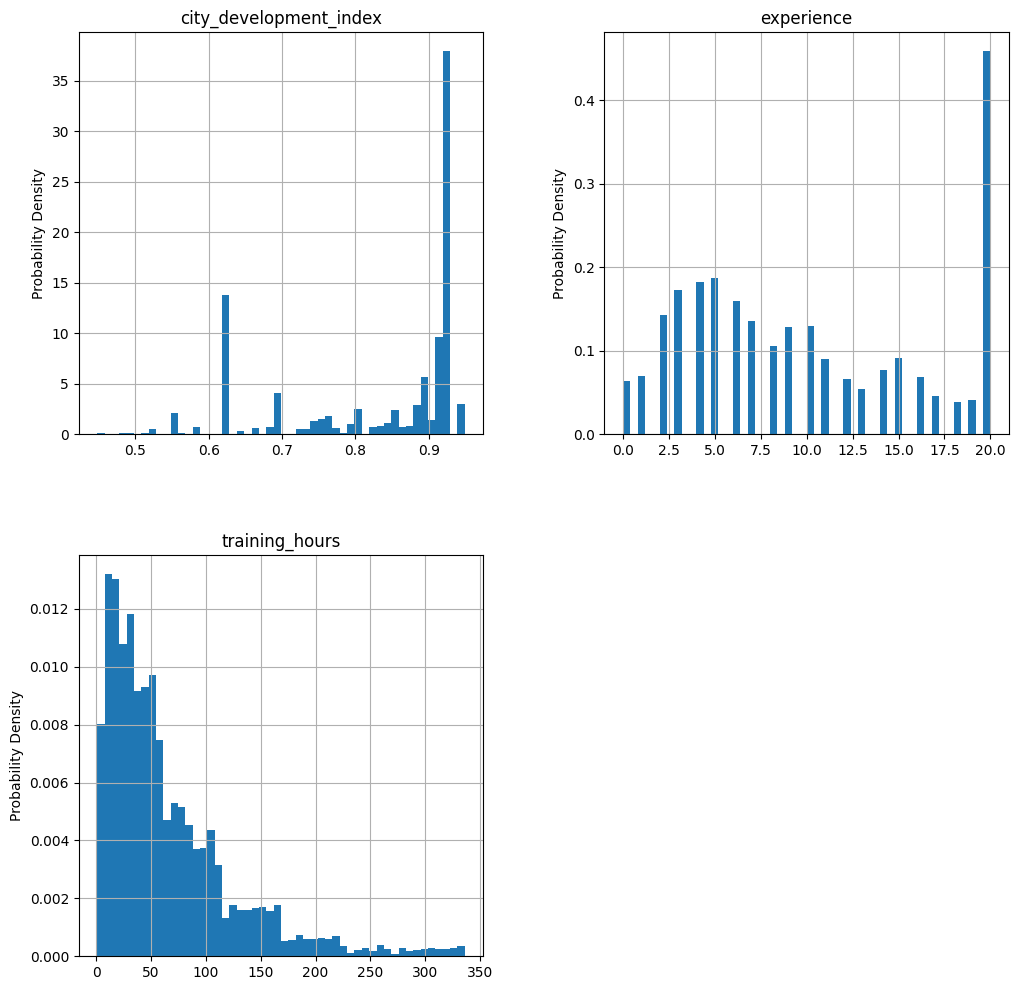

In [ ]:
import matplotlib.pyplot as plt  # needed for plotting

# Create histograms for all columns in the new DataFrame
#
# Explanation:
# - new_df.hist() will automatically create a histogram for *each numeric column*
# - bins=50 means the data will be divided into 50 intervals
# - density=True scales the histogram so the area under the bars sums to 1
#   (i.e., shows probability densities instead of raw counts)
# - figsize=(12,12) makes the overall figure larger and easier to read
#
# plt.show() actually displays the plots
axes = new_df.hist(bins=50, density=True, figsize=(12, 12))

# Add y-axis label to each subplot
for ax in axes.flatten():
    ax.set_ylabel("Probability Density")
plt.show()

---

✅ **Interpretation of the histograms**:

## 1️⃣ **city\_development\_index**

* The distribution is *strongly right-skewed* (most values near 0.9–1.0).
* That suggests most candidates come from highly developed cities (city development index close to 1.0).
* There are very few from cities with low development index (below 0.6).
* This is important because it might mean your data is biased toward candidates from more developed locations.

---

## 2️⃣ **experience**

* The bars are spread out with a strong spike at 20.
* That huge spike at the right (20) is suspicious — it may represent **“20+”** coded as 20, or a data-entry placeholder for “more than 20”.
* Otherwise, you see a more or less uniform spread between 1–15 years of experience.
* You might consider:

  * checking if 20 really means “20 years” or “20+”
  * binning experience into categories (e.g., 0–5, 5–10, etc.)

---

## 3️⃣ **training\_hours**

* This shows a classic *right-skew*: most people have fewer training hours (between 0–50 hours).
* A small number of people have very high training hours (over 200–300 hours), which may be rare.
* The long tail suggests there are some outliers — maybe people who did extensive training.
* Depending on your modeling, you might:

  * leave it as is
  * cap/extreme-limit it (winsorization)
  * log-transform it (to compress the outliers)

---

# ✅ Summary of what this means for you

* **city\_development\_index**: strongly biased toward highly developed cities
  👉 be cautious if generalizing results to less developed cities.

* **experience**: suspicious spike at 20
  👉 you may want to recode or group this variable.

* **training\_hours**: heavily right-skewed with some extreme high values
  👉 consider transformations or outlier treatment.

---


---

In this code, you specified:

```python
density=True
```

in the call to `hist()`.

👉 In **matplotlib** and **pandas**, setting `density=True` makes the histogram **normalize** the area under the bars to sum to 1. This means the y-axis is scaled to show a **probability density**, rather than raw counts.

Formally:

* When `density=False` (the default), the y-axis shows counts (how many records in each bin).
* When `density=True`, the y-axis shows the proportion of the total observations **per unit** on the x-axis, so the area under the histogram is 1. That’s exactly what we call a **probability density**.

---

✅ So in your code:

```python
df['training_hours'].hist(bins=50, density=True)
```

→ y-axis = probability density (the “height” of the distribution, integrating to 1 over the x-axis range).

---


# Comparing individual Columns before and after removing

Here we try understand if dropping the rows had a negative effect on the distribution

## Analyzing training_hours using histogram

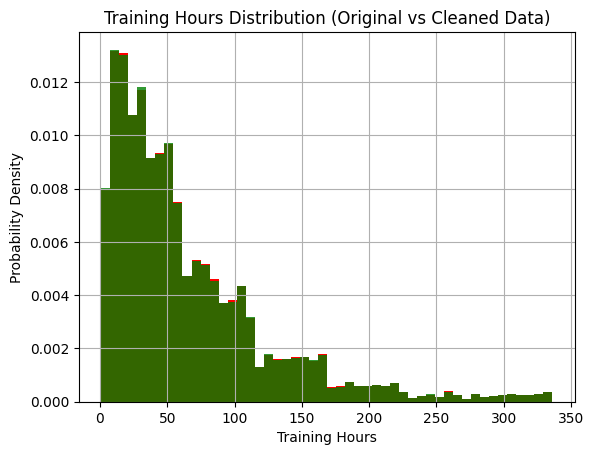

In [ ]:
import matplotlib.pyplot as plt

# Create a new figure
fig = plt.figure()

# Add a single subplot (1 row, 1 column, first plot)
ax = fig.add_subplot(111)

# Plot histogram of the original training_hours
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# Plot histogram of the cleaned training_hours
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

# Label the x-axis
ax.set_xlabel("Training Hours")

# Label the y-axis
ax.set_ylabel("Probability Density")

# Add a title (optional)
ax.set_title("Training Hours Distribution (Original vs Cleaned Data)")

plt.show()

---
👉 **Interpret what you see in this overlay histogram**:

✅ **Red bars**: original `training_hours` from the full dataset<br>
✅ **Green bars**: `training_hours` from the cleaned `new_df` (after dropping rows with missing values in those columns)<br>

---

## **What the plot shows:**

* The green bars (cleaned data) almost **completely overlap** the red bars (original data).
* This means **the distribution of `training_hours` did not change** after dropping rows with missing values in the other columns (from your `cols` selection).
* There is no big gap or shift, indicating you did not systematically lose or bias the training\_hours distribution by removing incomplete rows.

---

## **Conclusion:**

✅ You can safely continue using `new_df` without worrying about introducing bias in `training_hours`<br>
✅ The pattern (right-skewed, many low training hours, few very high) is preserved<br>

---

## Analyzing training_hours thru' density plot overlay

<Axes: ylabel='Density'>

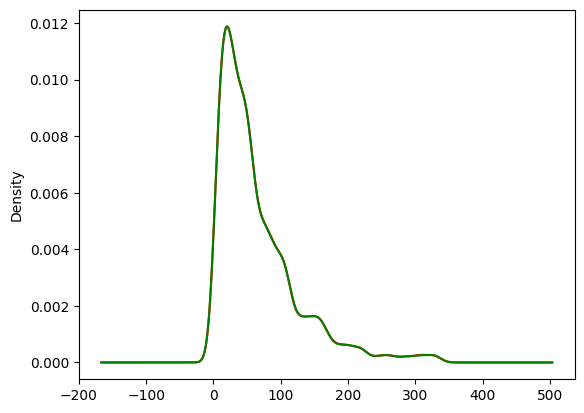

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

---

👉 **Interpreting this density plot overlay**:

✅ **Red line**: `training_hours` from the **original** dataset<br>
✅ **Green line**: `training_hours` after CCA (complete case analysis on selected columns)<br>

---

## **What you see**

* The **green density** (after dropping incomplete rows) almost perfectly overlaps the **red density** (original data).
* The density peaks around **0–20 training hours**, then trails off toward higher hours, with a long right tail (exactly like you saw in the histograms before).
* There are no major shifts between the red and green curves — they have the same:

  * **location** (peak around low hours)
  * **shape** (right-skewed)
  * **spread** (extending up to \~400 hours)

---

## **Conclusion**

✅ **Complete case analysis did not distort the training\_hours distribution.**

👉 In other words, the people you lost by dropping rows with missing data in the other columns do **not** have systematically different training\_hours patterns compared to the full dataset.

✅ That means you can keep using `new_df` for modeling involving `training_hours` with good confidence.

---

## Analyzing city_development_index using Histogram

<Axes: >

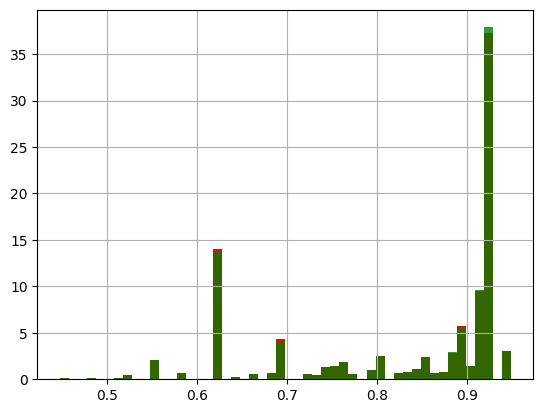

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

## Analyzing city_development_index using density plot

<Axes: ylabel='Density'>

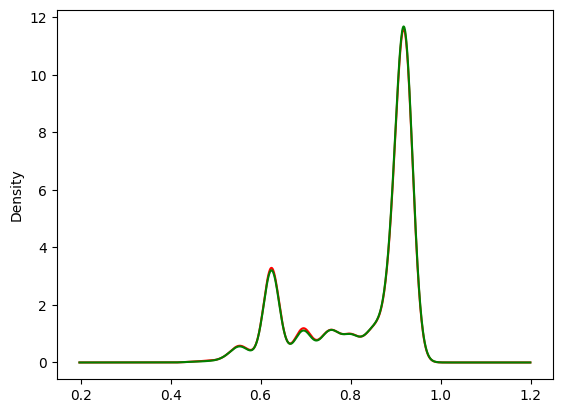

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

## Analyzing experience using histogram

<Axes: >

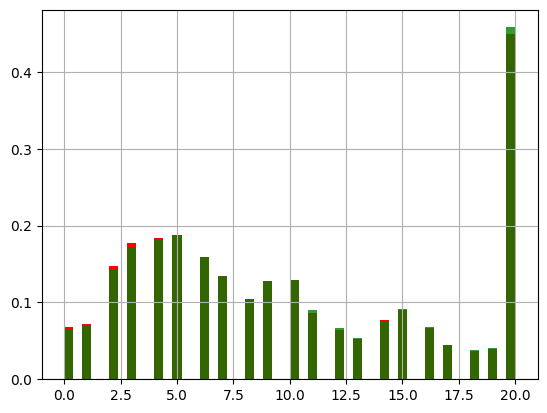

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

## Analyzing experience using density plot

<Axes: ylabel='Density'>

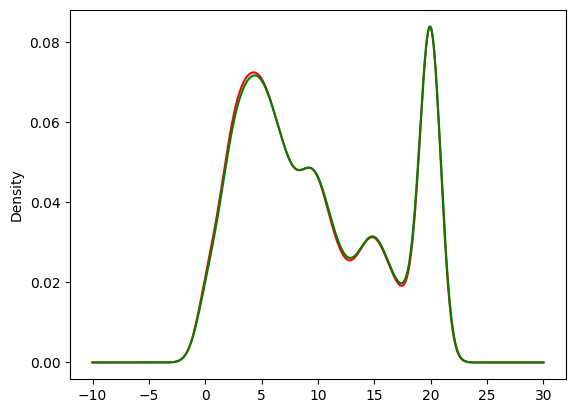

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

# Analyzing categorical columns

Before and After dataset should have the same ratios

In [ ]:
category_proportions = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
category_proportions.columns = ['original', 'cca']

category_proportions

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


---

## **What the table shows**

| enrolled\_university | Original (%) | After CCA (%) |
| -------------------- | ------------ | ------------- |
| no\_enrollment       | 72.1%        | 73.5%         |
| Full time course     | 19.6%        | 20.1%         |
| Part time course     | 6.3%         | 6.4%          |

---

✅ **Key observations:**

* The distributions of `enrolled_university` categories in the **original data** and in the **CCA data** are **very similar**.

  * `no_enrollment` shifts from 72.1% → 73.5% (tiny change)
  * `Full time course` from 19.6% → 20.1% (tiny change)
  * `Part time course` from 6.3% → 6.4% (tiny change)

✅ **Interpretation:**

* Performing **complete case analysis** did **not significantly distort** the distribution of `enrolled_university`.
* The relative proportions of each category are preserved, which is a good sign that CCA is safe here for this variable.

---

✅ **Why does this matter?**
If the category proportions had changed dramatically, it would suggest that rows with missing data had a very different enrollment pattern — leading to bias after applying CCA. But in your case, the proportions are essentially the same, so you can safely proceed with CCA for this column.

---

In [ ]:
category_proportions = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
category_proportions.columns = ['original', 'cca']

category_proportions

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
